In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

BASE = Path.cwd().parents[1] / 'data' / 'processed'
df = pd.read_parquet(BASE / 'dataset_consolidado.parquet')
df.index = pd.to_datetime(df.index)

train = df[df.index < '2025-07-13']['precio_bolsa']
test = df[df.index >= '2025-07-13']['precio_bolsa']

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# Normalizar
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
test_scaled = scaler.transform(test.values.reshape(-1, 1))

# Ventanas deslizantes
def crear_ventanas(data, ventana=30):
    X, y = [], []
    for i in range(len(data) - ventana):
        X.append(data[i:i+ventana])
        y.append(data[i+ventana])
    return np.array(X), np.array(y)

VENTANA = 30
X_train, y_train = crear_ventanas(train_scaled, VENTANA)
X_test, y_test = crear_ventanas(
    np.concatenate([train_scaled[-VENTANA:], test_scaled]), VENTANA
)

# Tensores
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)

dataset = TensorDataset(X_train_t, y_train_t)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Arquitectura GRU
class ModeloGRU(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                          batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

modelo_gru = ModeloGRU().to(device)
print(modelo_gru)
print(f"\nParámetros totales: {sum(p.numel() for p in modelo_gru.parameters()):,}")

ModeloGRU(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Parámetros totales: 37,889


In [2]:
criterio = nn.MSELoss()
optimizador = torch.optim.Adam(modelo_gru.parameters(), lr=0.001)

EPOCHS = 50
historial = []

for epoch in range(EPOCHS):
    modelo_gru.train()
    perdida_epoch = 0
    for X_batch, y_batch in loader:
        optimizador.zero_grad()
        pred = modelo_gru(X_batch)
        perdida = criterio(pred, y_batch)
        perdida.backward()
        optimizador.step()
        perdida_epoch += perdida.item()
    
    perdida_epoch /= len(loader)
    historial.append(perdida_epoch)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {perdida_epoch:.6f}")

print("Entrenamiento completo")

Epoch 10/50 — Loss: 0.000849
Epoch 20/50 — Loss: 0.000846
Epoch 30/50 — Loss: 0.000718
Epoch 40/50 — Loss: 0.000707
Epoch 50/50 — Loss: 0.000636
Entrenamiento completo


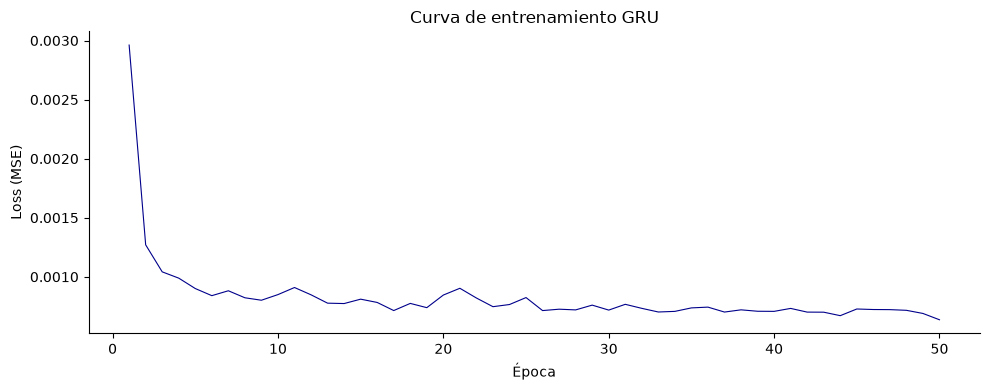

MAE:  31.62 $/kWh
RMSE: 44.89 $/kWh
MAPE: 14.32%


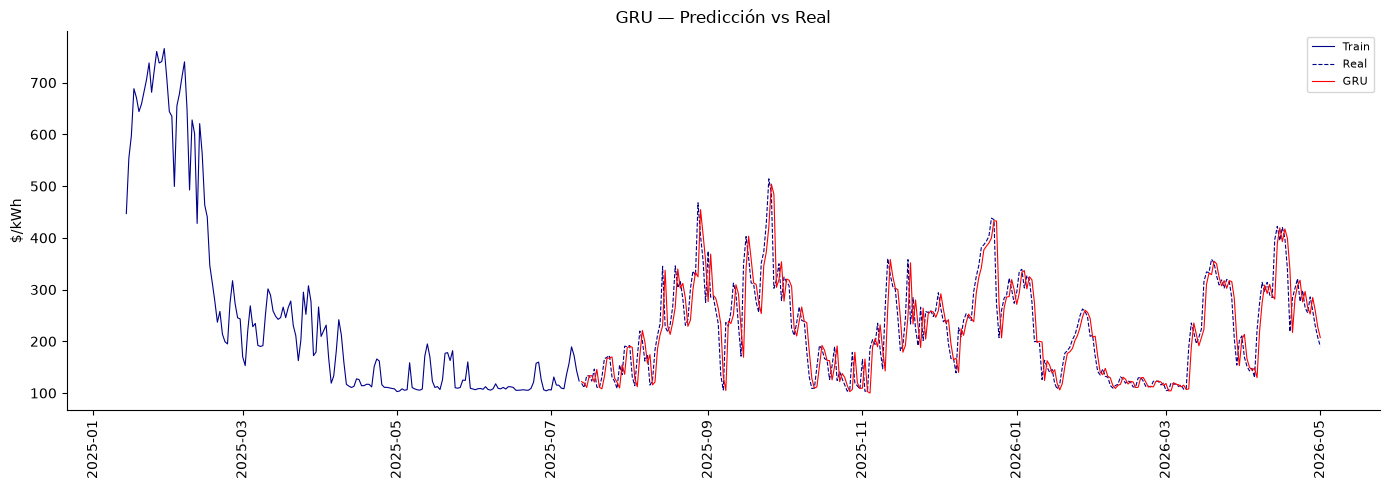

In [3]:
# Curva de entrenamiento
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, EPOCHS+1), historial, color='darkblue', linewidth=0.8)
ax.set_xlabel('Época')
ax.set_ylabel('Loss (MSE)')
ax.set_title('Curva de entrenamiento GRU')
sns.despine()
plt.tight_layout()
plt.show()

# Predicciones
modelo_gru.eval()
with torch.no_grad():
    pred_scaled = modelo_gru(X_test_t).cpu().numpy()

pred_gru = scaler.inverse_transform(pred_scaled).flatten()
real = test.values

mae_gru = np.mean(np.abs(real - pred_gru))
rmse_gru = np.sqrt(np.mean((real - pred_gru)**2))
mape_gru = np.mean(np.abs((real - pred_gru) / real)) * 100

print(f"MAE:  {mae_gru:.2f} $/kWh")
print(f"RMSE: {rmse_gru:.2f} $/kWh")
print(f"MAPE: {mape_gru:.2f}%")

# Gráfica
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index[-180:], train.values[-180:], color='darkblue', linewidth=0.8, label='Train')
ax.plot(test.index, real, color='darkblue', linewidth=0.8, linestyle='--', label='Real')
ax.plot(test.index, pred_gru, color='red', linewidth=0.8, label='GRU')
ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title('GRU — Predicción vs Real')
sns.despine()
plt.tight_layout()
plt.show()

In [6]:
PROCESSED = Path.cwd().parents[1] / 'data' / 'processed'

pred_df_dl = pd.read_parquet(PROCESSED / 'predicciones_dl.parquet')
pred_df_dl['gru'] = pred_gru
pred_df_dl.to_parquet(PROCESSED / 'predicciones_dl.parquet')
print("Guardado")

Guardado


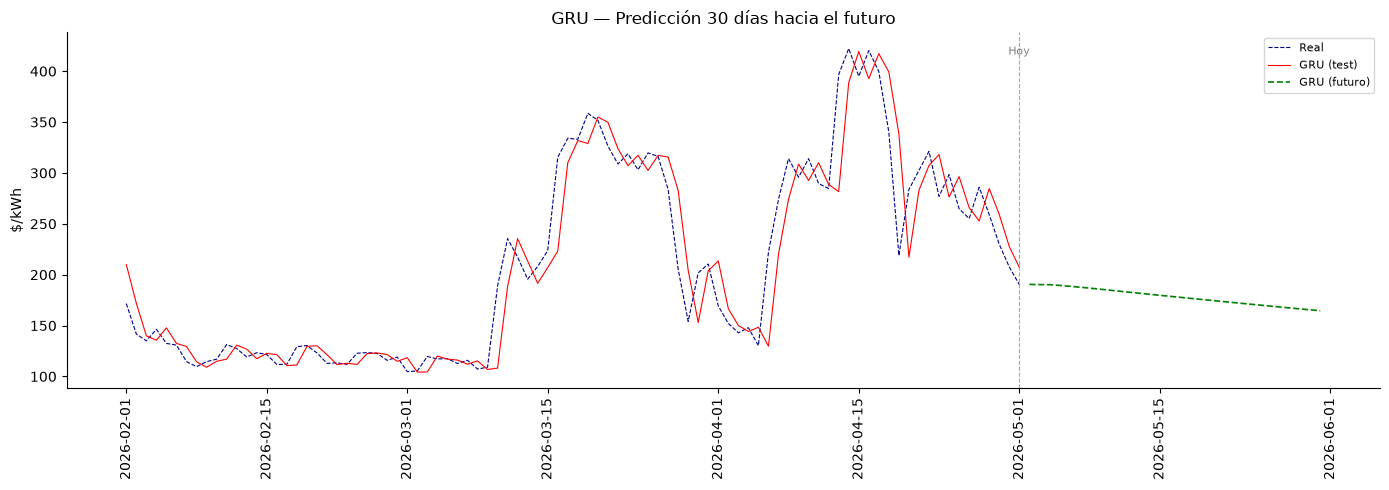


Predicción próximos 30 días:
            precio_bolsa_pred
2026-05-02             190.46
2026-05-03             190.26
2026-05-04             190.21
2026-05-05             189.47
2026-05-06             188.63
2026-05-07             187.75
2026-05-08             186.80
2026-05-09             185.80
2026-05-10             184.78
2026-05-11             183.76
2026-05-12             182.75
2026-05-13             181.75
2026-05-14             180.75
2026-05-15             179.75
2026-05-16             178.77
2026-05-17             177.78
2026-05-18             176.80
2026-05-19             175.83
2026-05-20             174.86
2026-05-21             173.89
2026-05-22             172.94
2026-05-23             171.98
2026-05-24             171.03
2026-05-25             170.09
2026-05-26             169.15
2026-05-27             168.22
2026-05-28             167.29
2026-05-29             166.36
2026-05-30             165.45
2026-05-31             164.53


In [7]:
ventana_inicial = test_scaled[-VENTANA:].reshape(1, VENTANA, 1)
ventana_actual = torch.FloatTensor(ventana_inicial).to(device)

predicciones_futuro = []

modelo_gru.eval()
with torch.no_grad():
    for _ in range(30):
        pred = modelo_gru(ventana_actual)
        predicciones_futuro.append(pred.item())
        nueva_ventana = torch.cat([ventana_actual[:, 1:, :], pred.unsqueeze(0)], dim=1)
        ventana_actual = nueva_ventana

pred_futuro_gru = scaler.inverse_transform(
    np.array(predicciones_futuro).reshape(-1, 1)
).flatten()

fechas_futuro = pd.date_range(
    start=test.index[-1] + pd.Timedelta(days=1), periods=30
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index[-90:], test.values[-90:], color='darkblue',
        linewidth=0.8, linestyle='--', label='Real')
ax.plot(test.index[-90:], pred_gru[-90:], color='red',
        linewidth=0.8, label='GRU (test)')
ax.plot(fechas_futuro, pred_futuro_gru, color='green',
        linewidth=1.2, linestyle='--', label='GRU (futuro)')
ax.axvline(test.index[-1], color='gray', linestyle='--',
           linewidth=0.8, alpha=0.7)
ax.text(test.index[-1], ax.get_ylim()[1]*0.95, 'Hoy',
        fontsize=8, color='gray', ha='center')
ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title('GRU — Predicción 30 días hacia el futuro')
sns.despine()
plt.tight_layout()
plt.show()

print("\nPredicción próximos 30 días:")
df_futuro = pd.DataFrame({'precio_bolsa_pred': pred_futuro_gru.round(2)}, index=fechas_futuro)
print(df_futuro)